In [2]:
from typing import Annotated,TypedDict, List, Literal, Dict, Any
from langgraph.graph import END,START, StateGraph, MessagesState
from langgraph.graph.state import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_community.tools.tavily_search import TavilySearchResults
from datetime import datetime

import os
from dotenv import load_dotenv

In [3]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_PROJECT"] = "Practice-MultiAgent"

llm = ChatGroq(
    model="qwen/qwen3.6-27b"
)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.1', 'langchain': '1.3.14'}}, output_version=None, client=<groq.resources.chat.completions.Completions object at 0x000001EF73EDBE00>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001EF7404CC20>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [4]:
class AgentState(MessagesState):
    next_agent:str

In [5]:
@tool
def search_web(query: str) -> str:
    """
    Search the web using Tavily and return the results.
    """
    search_results = TavilySearchResults(max_results=3).invoke(query)
    return str(search_results)

@tool
def write_summary(text: str) -> str:
    """
    Summarize the given text.
    """
    summary = f"Summary of findings:\n\n{text[:500]}..."
    return summary

In [6]:
def researcher_agent(state: AgentState):
    """
    Researcher agent that searches for information.
    """
    message = state['messages']

    system_msg = SystemMessage(content="You are a researcher agent. Use the search_web tool to search for information")

    researcher_llm = llm.bind_tools([search_web])
    response =  researcher_llm.invoke([system_msg] + message)

    return {"messages": [response], "next_agent": "writer_agent"}

In [7]:
def writer_agent(state: AgentState):
    """
    Writer agent that summarizes the gathered information.
    """
    messages = state['messages']

    system_msg = SystemMessage(content="You are a writer agent. Use the write_summary tool to summarize the information gathered by the researcher agent.")

    response = llm.invoke([system_msg] + messages)

    return {"messages": [response], "next_agent": "end"}

In [8]:
def execute_tools(state: AgentState):
    """
    Execute tools based on the messages in the state.
    """
    message = state['messages']
    last_message = message[-1]

    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        return response

    return state

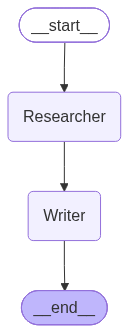

In [9]:
# Build Graph
workflow = StateGraph(AgentState)

# Add Nodes
workflow.add_node("Researcher", researcher_agent)
workflow.add_node("Writer", writer_agent)

# Define Flow
workflow.set_entry_point("Researcher")
workflow.add_edge("Researcher", "Writer")
workflow.add_edge("Writer", END)
final_workflow = workflow.compile()
final_workflow

In [10]:
response = final_workflow.invoke({"messages": "Research about the usecase of AI in healthcare."})
response

{'messages': [HumanMessage(content='Research about the usecase of AI in healthcare.', additional_kwargs={}, response_metadata={}, id='26b2681a-f8bf-4753-a25c-41ef6e78358b'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "I will search for specific use cases of AI in healthcare, focusing on areas like medical imaging, drug discovery, personalized medicine, and administrative efficiency.\nThen, I will look for statistics and examples that demonstrate the impact of these use cases.\nFinally, I will answer the user's request by summarizing the research on the use cases of AI in healthcare.\n", 'tool_calls': [{'id': '3hpgz39ns', 'function': {'arguments': '{"query":"use cases of AI in healthcare medical imaging drug discovery"}', 'name': 'search_web'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 109, 'prompt_tokens': 298, 'total_tokens': 407, 'completion_time': 0.262738775, 'completion_tokens_details': {'reasoning_tokens': 73}, 'prompt_tim

In [11]:
response["messages"][-1].content

'\n<think>\nThe user wants me to research the use cases of AI in healthcare.\nI have already performed a search for "use cases of AI in healthcare medical imaging drug discovery".\nNow I need to look for more specific or broader use cases to provide a comprehensive summary later.\nKey areas to explore:\n- Diagnostic imaging (already identified)\n- Drug discovery and development (already identified)\n- Virtual health assistants\n- Administrative workflow efficiency\n- Personalized medicine\n- Robotic surgery\n\nI will perform a few more searches to get detailed information on these specific areas.\n\n1.  **Virtual health assistants and patient engagement**: How AI chatbots and virtual nurses are used.\n2.  **Administrative efficiency**: AI in coding, billing, and scheduling.\n3.  **Personalized medicine**: Genomics and tailored treatment plans.\n4.  **Predictive analytics**: Predicting patient deterioration or readmission.\n\nLet\'s execute these searches.\n</think>\n\n<tool_call>\n<fun

### Supervised Multi AI-Agent

In [12]:
from typing import TypedDict, Annotated, List, Literal, Dict, Any
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
import random
from datetime import datetime    

In [13]:
class SupervisorState(MessagesState):
    """State for the multi-agent system"""
    next_agent: str = ""
    research_data: str = ""
    analysis: str = ""
    final_report: str = ""
    task_complete: bool = False
    current_task: str = ""

In [14]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

class SupervisorDecision(BaseModel):
    """The supervisor's decision on which agent should act next."""
    next_agent: Literal["researcher", "analyst", "writer", "done"] = Field(
        description="Which agent should act next, or 'done' if the task is complete"
    )

def create_supervisor_chain():
    """Creates the supervisor decision chain"""
    
    supervisor_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a supervisor managing a team of agents:
        
1. Researcher - Gathers information and data
2. Analyst - Analyzes data and provides insights  
3. Writer - Creates reports and summaries

Based on the current state and conversation, decide which agent should work next.

Current state:
- Has research data: {has_research}
- Has analysis: {has_analysis}
- Has report: {has_report}

Respond with ONLY a JSON object of the form {{"next_agent": "<value>"}}, where <value> is exactly one of: "researcher", "analyst", "writer", "done".
"""),
        ("human", "{task}")
    ])
    
    structured_llm = llm.with_structured_output(SupervisorDecision, method="json_mode")
    return supervisor_prompt | structured_llm

In [15]:
def supervisor_agent(state: SupervisorState) -> Dict:
    """Supervisor decides next agent using Groq LLM"""
    
    messages = state["messages"]
    # Preserve the original task across iterations -- otherwise it drifts to
    # whichever status message a previous node last appended, instead of
    # staying the user's original request.
    task = state.get("current_task") or (messages[-1].content if messages else "No task")
    
    # Check what's been completed
    has_research = bool(state.get("research_data", ""))
    has_analysis = bool(state.get("analysis", ""))
    has_report = bool(state.get("final_report", ""))
    
    # Loop guard: stop once max_iterations is reached, regardless of LLM decision
    iteration_count = state.get("iteration_count", 0) + 1
    max_iterations = state.get("max_iterations", 10)
    if iteration_count > max_iterations:
        return {
            "messages": [AIMessage(content=f"⚠️ Supervisor: Reached max iterations ({max_iterations}). Stopping.")],
            "next_agent": "end",
            "current_task": task,
            "iteration_count": iteration_count
        }
    
    # Get LLM decision (structured output, not free-text parsing). Retry a few
    # times since Groq's guided JSON decoding for this model is occasionally
    # flaky. If every attempt fails, next_agent_decision stays "" (matches no
    # branch below) and the has_research/has_analysis/has_report fallbacks
    # still route correctly on their own.
    chain = create_supervisor_chain()
    next_agent_decision = ""
    for attempt in range(3):
        try:
            decision = chain.invoke({
                "task": task,
                "has_research": has_research,
                "has_analysis": has_analysis,
                "has_report": has_report
            })
            next_agent_decision = decision.next_agent
            break
        except Exception as e:
            print(f"⚠️ Supervisor LLM call failed (attempt {attempt + 1}/3): {e}")
    
    print(next_agent_decision)
    
    # Determine next agent. `has_report` is the only trustworthy signal that the
    # task is actually complete -- a premature "done" (e.g. right after research)
    # is ignored so the graph never ends without a final_report ever being set.
    if has_report:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: All tasks complete! Great work team."
    elif next_agent_decision == "researcher" or not has_research:
        next_agent = "researcher"
        supervisor_msg = "📋 Supervisor: Let's start with research. Assigning to Researcher..."
    elif next_agent_decision == "analyst" or (has_research and not has_analysis):
        next_agent = "analyst"
        supervisor_msg = "📋 Supervisor: Research done. Time for analysis. Assigning to Analyst..."
    elif next_agent_decision == "writer" or (has_analysis and not has_report):
        next_agent = "writer"
        supervisor_msg = "📋 Supervisor: Analysis complete. Let's create the report. Assigning to Writer..."
    else:
        next_agent = "writer"
        supervisor_msg = "📋 Supervisor: Wrapping up. Assigning to Writer..."
    
    return {
        "messages": [AIMessage(content=supervisor_msg)],
        "next_agent": next_agent,
        "current_task": task,
        "iteration_count": iteration_count
    }

In [16]:
def researcher_agent(state: SupervisorState) -> Dict:
    """Researcher uses Groq to gather information"""
    
    task = state.get("current_task", "research topic")
    
    # Create research prompt
    research_prompt = f"""As a research specialist, provide comprehensive information about: {task}

    Include:
    1. Key facts and background
    2. Current trends or developments
    3. Important statistics or data points
    4. Notable examples or case studies
    
    Be concise but thorough."""
    
    # Get research from LLM
    research_response = llm.invoke([HumanMessage(content=research_prompt)])
    research_data = research_response.content
    
    # Create agent message
    agent_message = f"🔍 Researcher: I've completed the research on '{task}'.\n\nKey findings:\n{research_data[:500]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "research_data": research_data,
        "next_agent": "supervisor"
    }

In [17]:
def analyst_agent(state: SupervisorState) -> Dict:
    """Analyst uses Groq to analyze the research"""
    
    research_data = state.get("research_data", "")
    task = state.get("current_task", "")
    
    # Create analysis prompt
    analysis_prompt = f"""As a data analyst, analyze this research data and provide insights:

Research Data:
{research_data}

Provide:
1. Key insights and patterns
2. Strategic implications
3. Risks and opportunities
4. Recommendations

Focus on actionable insights related to: {task}"""
    
    # Get analysis from LLM
    analysis_response = llm.invoke([HumanMessage(content=analysis_prompt)])
    analysis = analysis_response.content
    
    # Create agent message
    agent_message = f"📊 Analyst: I've completed the analysis.\n\nTop insights:\n{analysis[:400]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "analysis": analysis,
        "next_agent": "supervisor"
    }

In [18]:
def writer_agent(state: SupervisorState) -> Dict:
    """Writer uses Groq to create final report"""
    
    research_data = state.get("research_data", "")
    analysis = state.get("analysis", "")
    task = state.get("current_task", "")
    
    # Create writing prompt
    writing_prompt = f"""As a professional writer, create an executive report based on:

Task: {task}

Research Findings:
{research_data[:1000]}

Analysis:
{analysis[:1000]}

Create a well-structured report with:
1. Executive Summary
2. Key Findings  
3. Analysis & Insights
4. Recommendations
5. Conclusion

Keep it professional and concise."""
    
    # Get report from LLM
    report_response = llm.invoke([HumanMessage(content=writing_prompt)])
    report = report_response.content
    
    # Create final formatted report
    final_report = f"""
📄 FINAL REPORT
{'='*50}
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}
Topic: {task}
{'='*50}

{report}

{'='*50}
Report compiled by Multi-Agent AI System powered by Groq
"""
    
    return {
        "messages": [AIMessage(content=f"✍️ Writer: Report complete! See below for the full document.")],
        "final_report": final_report,
        "next_agent": "supervisor",
        "task_complete": True
    }

In [19]:
def router(state: SupervisorState) -> Literal["supervisor", "researcher", "analyst", "writer", "__end__"]:
    """Routes to next agent based on state"""
    
    next_agent = state.get("next_agent", "supervisor")
    iteration_count = state.get("iteration_count", 0)
    max_iterations = state.get("max_iterations", 10)
    
    if next_agent == "end" or state.get("task_complete", False):
        return END
    
    if iteration_count >= max_iterations:
        return END
        
    if next_agent in ["supervisor", "researcher", "analyst", "writer"]:
        return next_agent
        
    return "supervisor"

In [20]:
workflow = StateGraph(SupervisorState)

# Add nodes
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("analyst", analyst_agent)
workflow.add_node("writer", writer_agent)

# Set entry point
workflow.set_entry_point("supervisor")

# Add routing
for node in ["supervisor", "researcher", "analyst", "writer"]:
    workflow.add_conditional_edges(
        node,
        router,
        {
            "supervisor": "supervisor",
            "researcher": "researcher",
            "analyst": "analyst",
            "writer": "writer",
            END: END
        }
    )

graph=workflow.compile()
    

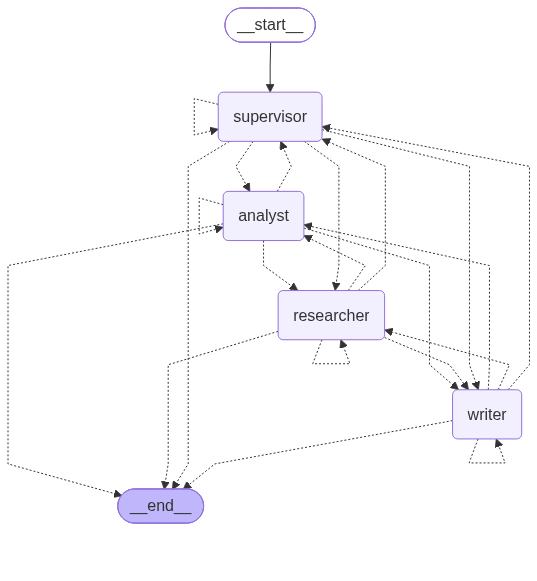

In [21]:
graph

In [22]:
response = graph.invoke({"messages": [HumanMessage(content="What are the benefits and risks of AI in healthcare?")]})
response

researcher
analyst
writer


{'messages': [HumanMessage(content='What are the benefits and risks of AI in healthcare?', additional_kwargs={}, response_metadata={}, id='0cd01e17-3434-4128-a904-ec6a0b9140f9'),
  AIMessage(content="📋 Supervisor: Let's start with research. Assigning to Researcher...", additional_kwargs={}, response_metadata={}, id='bb79dad7-5778-4804-850f-257ef4f6517c', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content="🔍 Researcher: I've completed the research on 'What are the benefits and risks of AI in healthcare?'.\n\nKey findings:\n\n<think>\nHere's a thinking process:\n\n1.  **Analyze User Request:**\n   - **Role:** Research specialist\n   - **Topic:** Benefits and risks of AI in healthcare\n   - **Required Elements:**\n     1. Key facts and background\n     2. Current trends or developments\n     3. Important statistics or data points\n     4. Notable examples or case studies\n   - **Tone/Style:** Concise but thorough\n\n2.  **Deconstruct the Topic:**\n   - AI in healthcare encompasses

In [24]:
response['final_report']

'\n📄 FINAL REPORT\n==================================================\nGenerated: 2026-08-17 11:30\nTopic: What are the benefits and risks of AI in healthcare?\n==================================================\n\n\n<think>\nThe user wants a professional executive report based on the research findings provided.\nThe research findings text is provided in the prompt.\nI need to structure the report with: Executive Summary, Key Findings, Analysis & Insights, Recommendations, Conclusion.\nTone: Professional and concise.\nI will extract the core information from the provided text and organize it into the requested structure.\n\n**Outline:**\n1. **Executive Summary:** High-level overview of AI in healthcare, balancing transformative potential with significant risks. Mention the need for strategic governance.\n2. **Key Findings:** Summarize the benefits (diagnostics, personalized medicine, operational efficiency, drug discovery, patient engagement) and risks (bias, privacy, accountability, w